In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [24]:
train_dataset = datasets.MNIST(
    root='../../../../my-practice/Dataset/amnist_data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='../../../../my-practice/Dataset/amnist_data',
    train=False,
    download=True,
    transform=transform # data preprocessing of a single batch done here.
)

In [25]:
# Load Dataset using DataLoader. DataLoader: Helps to load batch dataset. Create batches, Load data batch by batch to Dataset class for 
# preprocessed and then DataLoader provide the preprocessed data [ a single batch] to our model for calculation/prediction.
from torch.utils.data import DataLoader
train_loader = DataLoader(
    dataset=train_dataset, # provide single batch [data] to the dataset for preprocessing. Later, provide the preprocessed batch to our model
    batch_size=64, # create batches with 64 data [size]
    shuffle=True # When I want to distribute randomly
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

In [26]:
data_iter = iter(train_loader) # create iterable object using iter(), so that we can iterate the data [batch by batch]
images, labels = next(data_iter) # next() will iterate to next data [batch]

print(len(images)) # total images [hand written digit's image]
print(len(labels)) # real output [total images == total output(labels)]
print(images[63].shape) # all shape will be similar
print(labels[63]) # output will be digit 0 to 9 [any]

64
64
torch.Size([1, 28, 28])
tensor(7)


torch.Size([28, 28])


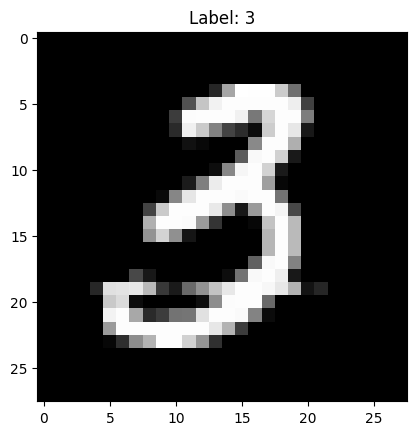

In [28]:
# How can we see and image
import matplotlib.pyplot as plt
image = images[0].squeeze() # convert shape(1,28,28) to shape(28,28) - squeeze() reduce a dimention.
print(image.shape)

plt.imshow(
    X=image, 
    cmap="gray"
)
plt.title(f"Label: {labels[0].item()}")
plt.show()